# Ⅲ. 분석

- **목적:** 교육 전후 평균 점수 차이를 검증하고,
그 효과의 통계적 유의성과 크기를 확인한다.

| 단계 | 내용 |
|------|------|
| 1 | 라이브러리 & 데이터 로드 |
| 2 | 기술통계 |
| 3 | 차이값 생성 |
| 4 | 분포 시각화 |
| 5 | 정규성 검증 (차이값 기준) |
| 6 | 통계 검정 |
| 7 | 효과 크기 (Cohen's d) |
| 8 | 평균 차이의 95% 신뢰구간 |
| 9 | Ceiling Effect 확인 |
| 10 | 세그먼트 분석 |

## 1. 라이브러리 & 데이터 로드

In [26]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, shapiro, wilcoxon
import scipy.stats as stats

# 글꼴 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [8]:
con = sqlite3.connect("../data/survey.db")
df = pd.read_sql("SELECT * FROM survey_clean", con)
con.close()

df.head()

,id,회차,직무,엑셀사용경력,사전_A,사전_B,사전_C,사후_A,사후_B,사후_C,사전_평균,사후_평균
0,R001,1회차,마케팅,1년 미만,3.0,2.5,3.0,4.5,3.5,4.5,2.833333,4.166667
1,R002,1회차,디자인,거의 없음,2.0,1.5,2.5,3.0,2.5,3.0,2.000000,2.833333
2,R003,1회차,마케팅,3년 이상,4.0,5.0,3.5,4.0,4.0,4.0,4.166667,4.000000
3,R004,1회차,마케팅,1~3년,3.5,2.5,3.0,5.0,4.0,4.0,3.000000,4.333333
4,R005,1회차,기획/전략,거의 없음,1.0,2.5,2.0,2.5,3.5,3.5,1.833333,3.166667


## 2. 기본 기술통계

In [9]:
df[["사전_평균", "사후_평균"]].describe()

,사전_평균,사후_평균
count,86.000000,86.000000
mean,2.792636,3.691860
std,0.591296,0.480004
min,1.500000,2.166667
25%,2.333333,3.333333
50%,2.833333,3.833333
75%,3.166667,4.000000
max,4.166667,4.500000


- 기술통계 분석 결과, 사후 평균(3.69)이 사전 평균(2.79) 대비 약 0.9점 상승하였다. 
- 또한 사후 표준편차가 더 낮게 나타나 교육 이후 점수가 일정 수준으로 수렴하는 경향을 보였다. 
- 사전·사후 표본 수가 동일(86명)하여 매칭이 적절히 수행되었음을 확인하였다. 
- 다만 평균 차이의 통계적 유의성을 검증하기 위해 대응표본 t-test를 추가 수행하였다.

## 3. 차이값 생성

- 대응표본 t-test는 동일 집단의 사전-사후 차이값 평균이 0인지 검정하는 것임.
- 따라서 차이값 컬럼을 별도로 생성함.

In [10]:
df["difference"] = df["사후_평균"] - df["사전_평균"]

df["difference"].describe()

count    86.000000
mean      0.899225
std       0.339433
min      -0.166667
25%       0.666667
50%       0.833333
75%       1.166667
max       1.666667
Name: difference, dtype: float64

## 4. 분포 시각화

### 사전 vs 사후 박스 플롯

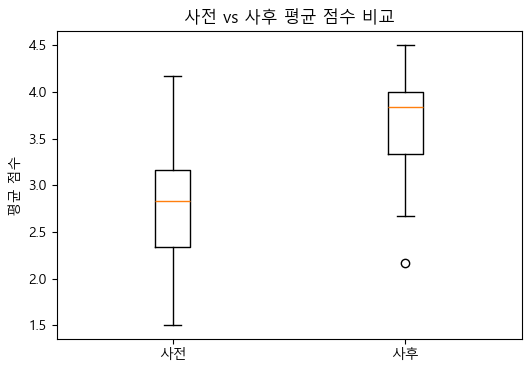

In [15]:
plt.figure(figsize=(6, 4))
plt.boxplot([df["사전_평균"], df["사후_평균"]])
plt.xticks([1, 2], ["사전", "사후"])
plt.title("사전 vs 사후 평균 점수 비교")
plt.ylabel("평균 점수")
plt.show()

- 사후 점수 분포가 사전에 비해 전반적으로 상승함.

### 개선 점수 분포

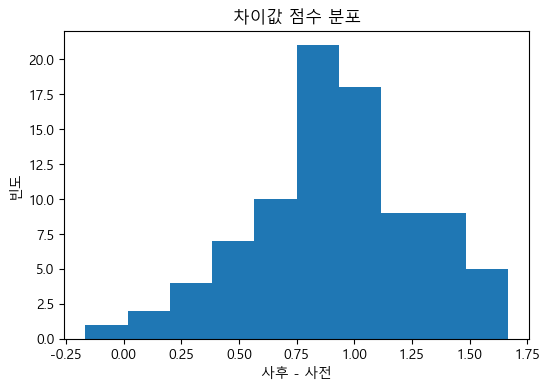

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df["difference"], bins=10)
plt.title("차이값 점수 분포")
plt.xlabel("사후 - 사전")
plt.ylabel("빈도")
plt.show()

## 5. 정규성 검증 (차이값 기준)

#### 판단 기준
- p > 0.05 → 정규성 가정 충족
- p ≤ 0.05 → 정규성 가정 위반

In [17]:
stat, p_normal = shapiro(df["difference"])
print("Shapiro-Wilk p-value: ", p_normal)

Shapiro-Wilk p-value:  0.03897641187598586


- Shapiro-Wilk 정규성 검정 결과, p-value ≈ 0.03으로 나타났다.
이는 유의수준 0.05 기준에서 차이값 분포가 통계적으로 정규성을 완전히 만족하지 않음을 의미한다.
- 다만 본 설문의 표본 수는 86명으로, 일반적으로 **n ≥ 30**일 경우 중심극한정리에 의해 **표본 평균의 분포는 정규분포에 근사한다**고 알려져 있다. 따라서 차이값 분포가 완전한 정규성을 따르지 않더라도, **대응표본 t-test 적용은 실무적으로 타당하다**고 판단하였다.
- 한편, 극단값이 정규성 검정 결과에 영향을 주었을 가능성을 고려하여, 차이값에 대해 ***IQR(사분위 범위) 기준을 활용한 이상치 탐색**을 추가로 수행하였다.

### IQR 방식으로 이상치 탐색

In [22]:
Q1 = df["difference"].quantile(0.25)
Q3 = df["difference"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df["difference"] < lower_bound) | (df["difference"] > upper_bound)
]

print("lower_bound:", lower_bound) 
print("upper_bound:", upper_bound) 
print("outliers_iqr:\n", outliers_iqr)

lower_bound: -0.08333333333333237
upper_bound: 1.9166666666666659
outliers_iqr:
      id   회차   직무 엑셀사용경력  사전_A  사전_B  사전_C  사후_A  사후_B  사후_C     사전_평균  사후_평균  \
2  R003  1회차  마케팅  3년 이상   4.0   5.0   3.5   4.0   4.0   4.0  4.166667    4.0   

   difference  
2   -0.166667  


- IQR 기준으로 차이값의 이상치를 탐색한 결과, **1건**이 경계값을 벗어났다.
- 해당 사례는 **사후 점수가 사전 대비 감소**한 사례로, 감소폭은 -0.17점이다.
- 입력 오류나 비정상 수치로 판단되지 않았으므로, 따라서 데이터 왜곡 가능성이 낮다고 판단하여 **해당 표본을 포함한 상태**로 분석을 진행하였다.

### 이상치 제거 후 Shapiro-Wilk 다시 수행

- 이상치가 얼마나 정규성에 영향을 주었는지 확인하기 위하여
    - 이상치를 제거한 후 Shapiro-Wilk를 다시 수행하였다.

In [23]:
df_no_outlier = df[
    (df["difference"] >= lower_bound) &
    (df["difference"] <= upper_bound)
]

In [24]:
stat_clean, p_normal_clean = shapiro(df_no_outlier["difference"])

print("Shapiro-Wilk p-value (이상치 제거 후):", p_normal_clean)

Shapiro-Wilk p-value (이상치 제거 후): 0.04984752036303178


- Shapiro-Wilk test는 표본이 적을수록 사소한 왜도나 꼬리에도 민감하게 바응함.
- 지금 p값이 0.04 정도 되는데, 경계값 0.05와 비슷한 상황임.
- 완전히 비정규 분포라고 하기에, 정규 분포라고 하기에도 애매한 상황임.

- 이상치 1건 제거 후에도 Shapiro-Wilk 검정 결과 p=0.0498로, 정규성 가정이 엄밀히 충족되지는 않았다. 
- 이는 극단값의 영향보다는 **분포 자체의 경미한 비정규성**에 기인한 것으로 판단된다. - 다만 표본 수가 86명으로 충분히 크므로 중심극한정리에 따라 대응표본 t-test 적용은 실무적으로 타당하다고 보았다.

- Shapiro-Wilk 검정 결과 정규성 가정이 경계선 수준에서 충족되지 않아, **대응표본 t-test**와 **Wilcoxon Signed-Rank Test**를 모두 수행하였다.

## 6. 통계 검정

### 대응표본 t-test

- 동일 집단의 사전·사후 평균 차이가 통계적으로 유의한지를 검정하는 모수 검정 방법

In [25]:
t_stat, p_value = ttest_rel(df["사후_평균"], df["사전_평균"])
print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 24.567606361261568
p-value: 2.2461897526583046e-40


### Wilcoxon Signed-Rank Test 수행

- 동일 집단의 사전·사후 순위 기반 차이가 유의한지를 검정하는 비모수 검정 방법

In [27]:
stat, p_value = wilcoxon(df["사후_평균"], df["사전_평균"])
print("Wilcoxon p-value:", p_value)

Wilcoxon p-value: 7.618210813223991e-16


- 모수 검정인 대응표본 t-test 결과, 사전 대비 사후 점수는 통계적으로 유의하게 증가하였다(t = 24.57, p < .001).
- 비모수 검정인 Wilcoxon 검정에서도 동일한 결과가 확인되었다(p < .001).
- 따라서 본 교육은 **통계적으로 유의한 점수 향상**을 유발한 것으로 판단된다.

## 7. 효과 크기 (Cohen’s d)

#### 판단 기준
- 0.2 이하 (Small): 작은 효과 (평균 차이가 작음)
- 0.5 기준 (Medium): 중간 효과 (평균 차이가 눈으로 보임)
- 0.8 이상 (Large): 큰 효과 (평균 차이가 확연함) 

In [30]:
mean_diff = df["difference"].mean()
std_diff = df["difference"].std()

# 차이값 평균 ÷ 차이값 표준편차
cohens_d = mean_diff / std_diff
print("Cohen's d:", cohens_d)

Cohen's d: 2.649193124905269


- Cohen’s d는 2.65로 매우 큰 효과 크기를 보였다.
- 이는 평균 상승폭이 개인 간 변동성 대비 매우 크게 나타났기 때문으로, **응답자 대부분이 유사한 수준의 점수 향상**을 보였음을 시사한다. (표준편차가 매우 낮다는 의미)

- 현실적인 이유
    - 철문 척도의 한계: 5점 사전 vs 사후 척도 -> 상승 여지가 비슷하게 제한
    - 교육 직후 측정이라 대부분 긍정적 반응 -> 응답이 몰림
    - 자기평가 척도: 객관적인 시험이 아니라 자가 평가라 체감 상승이 비슷하게 나타남

## 8. 평균 차이의 95% 신뢰구간

In [32]:
se = stats.sem(df["difference"])

ci = stats.t.interval(
    0.95,
    len(df["difference"]) - 1,
    loc=mean_diff,
    scale=se
)

print("95% 신뢰구간:", ci)

95% 신뢰구간: (np.float64(0.826450120809442), np.float64(0.9719994915936584))


- 평균 차이(사후−사전)는 0.826점 ~ 0.972점 사이에 있을 것으로 95% 신뢰한다.

- 평균 차이의 95% 신뢰구간은 (0.826, 0.972)로 나타났으며, 이는 교육 이후 점수가 최소 약 0.83점 이상 상승했음을 의미한다. 
- 신뢰구간에 0이 포함되지 않아 평균 차이는 통계적으로 유의하며, 실질적으로도 의미 있는 수준의 향상으로 해석된다.

## 9. Ceiling Effect 확인

- Ceiling effect: 점수가 이미 최대치에 가까워 추가 향상이 측정되지 않는 현상
    - 예: 5점 만점 설문에서
        - 사전 점수가 이미 4.8, 4.9 이런 상태라면 교육을 받아도 5 이상 줄 수 없기 때문에
        - 실제 향상이 있어도 점수는 거의 안 변한다.

In [33]:
print("사전 만점 비율:", (df["사전_평균"] == 5).mean()) 
print("사후 만점 비율:", (df["사후_평균"] == 5).mean())

사전 만점 비율: 0.0
사후 만점 비율: 0.0


In [34]:
print("사전 4.5 이상 비율:", (df["사전_평균"] >= 4.5).mean())
print("사후 4.5 이상 비율:", (df["사후_평균"] >= 4.5).mean())

사전 4.5 이상 비율: 0.0
사후 4.5 이상 비율: 0.011627906976744186


- 점수 상한에 의한 왜곡 가능성을 점검하기 위해 사전·사후 평균 점수의 상위 구간 비율을 확인하였다. 
- 사전 점수는 중간 수준에 분포되어 있어 천장 효과에 따른 왜곡 가능성은 낮은 것으로 판단된다.

### 통계 검증 결과 요약

- 평균 상승: +0.899
- Shapiro-Wilk p-value: 0.038
- t-test: 유의
- Wilcoxon: 유의
- Cohen’s d: 2.65 (매우 큼)
- 95% CI: (0.826 ~ 0.972)
- Ceiling Effect 없음.

## 10. 세그먼트 분석

### 엑셀 사용 경력

In [35]:
df.groupby("엑셀사용경력")["difference"].agg(["mean", "count"])

,mean,count
엑셀사용경력,,
1~3년,0.929487,26
1년 미만,0.993333,25
3년 이상,0.626984,21
거의 없음,1.083333,14


- 초보자일수록 교육 전후 차이값의 상승폭이 큼
- 숙련자(3년 이상)는 상승폭이 상대적으로 작음
- 교육 효과는 기초 수준 참여자에게 더 크게 작용했을 가능성이 있음.

### 직무별

In [36]:
df.groupby("직무")["difference"].agg(["mean", "count"])

,mean,count
직무,,
기획/전략,0.895833,24
디자인,0.870370,18
마케팅,0.893939,33
영업,0.969697,11


- 직무 간 교육 전후 차이값의 차이는 크지 않음
- 모든 직무에서 유사한 수준의 상승

### 회차별

In [37]:
df.groupby("회차")["difference"].agg(["mean", "count"])

,mean,count
회차,,
1회차,0.854167,16
2회차,1.000000,19
3회차,0.937500,16
4회차,0.912698,21
5회차,0.750000,14


- 2회차에서 가장 큰 상승
- 5회차에서 가장 낮은 상승
- 회차별 운영 안정성 점검 필요함.

### 세그먼트 분석 결론

- 세그먼트 분석 결과, 교육 효과는 전반적으로 모든 직무에서 유사하게 나타났다. 
- 다만 엑셀 사용 경험이 적은 참여자일수록 평균 상승폭이 크게 나타나, 본 교육은 기초 역량 강화에 특히 효과적인 것으로 해석된다. 
- 회차별로는 일부 편차가 관찰되었으나 전반적으로 모든 회차에서 유의미한 상승이 확인되었다